# E-commerce Data Analysis

## PROJECT DESCRIPTION


**PROJECT DESCRIPTION AND OBJECTIVE.** Analysis of data from a large e-commerce platform to increase revenue: hypothesis prioritization, A/B test implementation, and results analysis.

---

**Data Description**

File: `/datasets/hypothesis.csv`

- Hypothesis — brief description of the hypothesis  
- Reach — user reach (scale 1–10)  
- Impact — impact on users (scale 1–10)  
- Confidence — confidence in the hypothesis (scale 1–10)  
- Efforts — resources required to test the hypothesis (scale 1–10). The higher the Efforts value, the more expensive the test  

---

File: `/datasets/orders.csv`

- transactionId — order ID  
- visitorId — user ID  
- date — order date  
- revenue — order revenue  
- group — A/B test group  

---

File: `/datasets/visitors.csv`

- date — date  
- group — A/B test group  
- visitors — number of users per date per group  

---

**Project Plan**

Data loading, initial exploration, and preprocessing  

---

**Part 1. Hypothesis Prioritization**

- Applying the ICE framework to prioritize hypotheses  
- Applying the RICE framework to prioritize hypotheses  
- Analyzing how prioritization changes when using RICE instead of ICE  

---

**Part 2. A/B Test Analysis**

- Building a cumulative revenue graph by group  
- Building a cumulative average order value (AOV) graph by group  
- Building a relative change graph of cumulative AOV (Group B vs Group A)  
- Building a cumulative average number of orders per visitor graph and drawing conclusions  
- Building a relative change graph of average orders per visitor (Group B vs Group A)  
- Building a scatter plot of orders per user  
- Calculating the 95th and 99th percentiles of orders per user and defining thresholds for anomalies  
- Building a scatter plot of order values  
- Calculating the 95th and 99th percentiles of order values and defining thresholds for anomalies  
- Calculating statistical significance of differences in average orders per visitor between groups (raw data)  
- Calculating statistical significance of differences in average order value between groups (raw data)  
- Calculating statistical significance of differences in average orders per visitor between groups (filtered data)  
- Calculating statistical significance of differences in average order value between groups (filtered data)  
- Final conclusions and recommendations  

## 1 Загрузка данных, изучение общей информации и предобработка данных

### Импорт библиотек

In [1]:
# Импорт стандартных библиотек для работы с датами и предупреждениями
from datetime import datetime, timedelta
import datetime as dt
import warnings

# Импорт библиотек для анализа и обработки данных
import pandas as pd
import numpy as np
import scipy.stats as stats
from pandas.plotting import register_matplotlib_converters

# Импорт библиотек для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

### Загрузка файлов

In [2]:
#загрузим данные из локальных файлов, а если они не доступны 
#(например, если скрипт выполняется в другой среде или нет доступа к локальным файлам), 
#он загружает их из удалённых URL-адресов
try:
    hypothesis = pd.read_csv('/datasets/hypothesis.csv')
    orders = pd.read_csv('/datasets/orders.csv')
    visitors = pd.read_csv('/datasets/visitors.csv')
    
except:
    hypothesis = pd.read_csv('https://code.s3.yandex.net/datasets/hypothesis.csv')
    orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders.csv')
    visitors = pd.read_csv('https://code.s3.yandex.net/datasets/visitors.csv')

### Изучение общей информации о датафреймах

In [3]:
# выведем на экран первые 5 строчек и общую информацию по датафреймам hypothesis
display(hypothesis.head())
hypothesis.info()

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [4]:
# выведем на экран первые 5 строчек и общую информацию по датафреймам orders 
display(orders.head())
orders.info()


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [5]:
# выведем на экран первые 5 строчек и общую информацию по датафреймам visitors
display(visitors.head())
visitors.info()

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


**ВЫВОД**
Анализ данных показал, что в датафреймах:
- hypothesis
  - 9 строк
  - Столбцы:
     - Reach, Impact, Confidence и Efforts - целочисленный тип int64
     - Hypothesis- тип object

- orders
  - 1197 строк
  - Столбцы:
     - transactionId, visitorId и revenue — целочисленный тип int64
     - date и group — тип object
     
- visitors
  - 62 строки
  - Столбцы:
      - date и group — тип object 
      - visitors — целочисленный тип int64 

Рекомендации:
-  следует  преобразовать в датафреймах orders и visitors тип данных в колонке date — на текущий момент тип object, а нужно преобразвать в тип datetime64[ns].
-  следует преобразовать названия столбцов к нижнему регистру и с нижним подчеркиванием

### Выполнение предобработки данных

#### Преобразование названий столбцов

In [6]:
# Преобразование названий столбцов к нижнему регистру датафреймов и замена пробелов на подчеркивания
hypothesis.columns = [x.lower().replace(' ', '_') for x in hypothesis.columns.values]
orders.columns = [x.lower().replace(' ', '_') for x in orders.columns.values]
visitors.columns = [x.lower().replace(' ', '_') for x in visitors.columns.values]

#проверим выполнились ли преобразования, выведем названия столбцов
display(hypothesis.columns)
display(orders.columns)
display(visitors.columns)

Index(['hypothesis', 'reach', 'impact', 'confidence', 'efforts'], dtype='object')

Index(['transactionid', 'visitorid', 'date', 'revenue', 'group'], dtype='object')

Index(['date', 'group', 'visitors'], dtype='object')

In [7]:
#заменим названия для наглядности с нижним подчеркиванием в датафрейме orders
orders = orders.rename(columns={'transactionid': 'transaction_id', 'visitorid': 'visitor_id'}) 

#проверим, выполнились ли преобразования, выведем названия столбцов
display(orders.columns)

Index(['transaction_id', 'visitor_id', 'date', 'revenue', 'group'], dtype='object')

#### Преобразование к нужному типу данных

In [8]:
# Преобразуем тип данных в тип datetime в датафреймах orders и visitors
orders['date'] = pd.to_datetime(orders['date'])
visitors['date'] = pd.to_datetime(visitors['date'])

# проверим, выполнились ли преобразования, выведем тип данных в столбце 'date' в датафреймах orders и visitors
print("Тип данных в столбце 'date' в orders:", orders['date'].dtypes)
print("Тип данных в столбце 'date' в visitors:", visitors['date'].dtypes)

Тип данных в столбце 'date' в orders: datetime64[ns]
Тип данных в столбце 'date' в visitors: datetime64[ns]


#### Наличие пропусков

In [9]:
# проверим на наличие пропусков наши датафреймы
display("Количество пропусков в hypothesis:", hypothesis.isnull().sum())

display("Количество пропусков в orders:", orders.isnull().sum())

display("Количество пропусков в visitors:", visitors.isnull().sum())

'Количество пропусков в hypothesis:'

hypothesis    0
reach         0
impact        0
confidence    0
efforts       0
dtype: int64

'Количество пропусков в orders:'

transaction_id    0
visitor_id        0
date              0
revenue           0
group             0
dtype: int64

'Количество пропусков в visitors:'

date        0
group       0
visitors    0
dtype: int64

#### Проверка на наличие явных дубликатов

In [10]:
#выведем на экран данные о дубликатах
display("Полных дубликатов в hypothesis:", hypothesis.duplicated().sum())
display("Полных дубликатов в orders:", orders.duplicated().sum())
display("Полных дубликатов в visitors:", visitors.duplicated().sum())

'Полных дубликатов в hypothesis:'

0

'Полных дубликатов в orders:'

0

'Полных дубликатов в visitors:'

0

**ВЫВОД**
- Названия столбцов в исследуемых датафреймах hypothesis, orders и visitors преобразовались в нижний регистр и с нижним подчеркиванием
- Тип данных в orders и visitors преобразовался в тип datetime
- В исследуемых данных нет пропусков
- В  датафреймах hypothesis, orders и visitors нет явных дубликатов

#### Проверка на наличие пользователей в двух группах

В A/B тестировании каждый пользователь должен быть только в одной группе. Если кто-то оказался и в A, и в B — это ошибка логирования и такие пользователи искажают результаты.

In [11]:
# Найдём пользователей, оказавшихся в обеих группах
users_A = orders[orders['group'] == 'A']['visitor_id']
users_B = orders[orders['group'] == 'B']['visitor_id']
users_in_both_groups = np.intersect1d(users_A, users_B)

print(f'Пользователей в обеих группах: {len(users_in_both_groups)}')

# Удалим этих пользователей из таблицы orders
orders_new = orders[~orders['visitor_id'].isin(users_in_both_groups)]

print(f'Размер исходной таблицы orders: {orders.shape[0]} строк')
print(f'Размер очищенной таблицы: {orders_new.shape[0]} строк')

orders = orders_new  # окончательная замена

Пользователей в обеих группах: 58
Размер исходной таблицы orders: 1197 строк
Размер очищенной таблицы: 1016 строк


In [12]:
# проверим, сохраеились ли данные в orders
display(orders.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1016 non-null   int64         
 1   visitor_id      1016 non-null   int64         
 2   date            1016 non-null   datetime64[ns]
 3   revenue         1016 non-null   int64         
 4   group           1016 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 47.6+ KB


None

**ВЫВОД**
- В ходе анализа выявлено, что 58 пользователей оказались одновременно в группах A и B, что нарушает принцип независимости групп в A/B-тестировании.
- Эти пользователи были исключены из анализа, поскольку их поведение может исказить результаты теста.
- После удаления пересекающихся пользователей: объём данных уменьшился с 1197 до 1016 заказов.
- Обе группы стали полностью независимыми, что позволяет корректно оценить статистическую значимость различий между ними.

## Часть 1. Приоритизация гипотез

### Применение фреймворка ICE для приоритизации гипотез

In [13]:
# Расчёт ICE по формуле с efforts (обратная пропорция), с окрглением результата - два знака после запятой
hypothesis['ICE'] = round(((hypothesis['impact'] * hypothesis['confidence']) / hypothesis['efforts']),2)

# Сортировка по ICE по убыванию
sorted_data = hypothesis.sort_values(by='ICE', ascending=False)

#зададим параметр отображения полной строки без обрезания 
pd.set_option('display.max_colwidth', None) 

# Вывод нужных столбцов
display(sorted_data[['hypothesis', 'ICE']])

,hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.00


**ВЫВОД:** 
наиболее перспективные гипотезы по ICE: 8, 0, 7, а именно:
- Запустить акцию, дающую скидку на товар в день рождения
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок

### Применение фреймворка RICE для приоритизации гипотез

In [14]:
# Расчёт RICE и добавление в таблицу
hypothesis['RICE'] = round(((hypothesis['reach'] * hypothesis['impact'] * hypothesis['confidence']) / hypothesis['efforts']), 2)

# Сортировка по RICE по убыванию
sorted_data_rice = hypothesis.sort_values(by='RICE', ascending=False)

# Вывод только нужных столбцов
print(sorted_data_rice[['hypothesis', 'RICE']])

                                                                                                     hypothesis  \
7              Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок   
2  Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа   
0            Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей   
6          Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию   
8                                                       Запустить акцию, дающую скидку на товар в день рождения   
3           Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар   
1                                     Запустить собственную службу доставки, что сократит срок доставки заказов   
5                      Добавить страницу отзывов клиентов о магазине, что позвол

**ВЫВОД** наиболее перспективные гипотезы по RICE: 7, 2, 0 и 6, а именно:
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок   
- Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей
- Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию



### Изменение в приоритизации гипотез при применении RICE вместо ICE

Как изменилась приоритизация гипотез при переходе с ICE на RICE:

- Гипотеза 8 (скидка на день рождения) была на первом месте по ICE, но сильно опустилась в RICE — потому что её охват очень ограничен (только пользователи в день рождения).
- Гипотеза 7 (форма подписки) поднялась с 3 места (ICE) на 1 место в RICE, потому что она затрагивает всех пользователей на сайте — её охват очень высокий.
- Гипотеза 2 (рекомендации товаров) поднялась вверх по RICE, хотя в ICE была ниже — потому что её эффект масштабируется на многих пользователей.
- Гипотеза 0 (новые каналы трафика) стабильно высоко в обоих фреймворках, т.к. сочетает высокий охват и ценность.

Почему так произошло:
- ICE оценивает, насколько гипотеза эффективна сама по себе, но не учитывает насколько массовое её применение.
- RICE добавляет критически важный фактор — Reach (охват), что делает оценку более реалистичной в бизнесе.
- RICE даёт более стратегичный приоритет, учитывая масштаб воздействия гипотезы. Гипотезы с высоким охватом, пусть и не с самой большой силой эффекта, могут принести больше пользы в сумме.

## Часть 2. Анализ A/B-теста

### Построение графика кумулятивной выручки по группам

In [15]:
# создаем массив уникальных пар значений дат и групп теста
datesGroups = orders[['date', 'group']].drop_duplicates()

# получаем агрегированные кумулятивные по дням данные о заказах 
ordersAggregated = datesGroups.apply(
    lambda x: orders[
        np.logical_and(
            orders['date'] <= x['date'], orders['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transaction_id': 'nunique',
            'visitor_id': 'nunique',
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])

# получаем агрегированные кумулятивные по дням данные о посетителях интернет-магазина 
visitorsAggregated = datesGroups.apply(
    lambda x: visitors[
        np.logical_and(
            visitors['date'] <= x['date'], visitors['group'] == x['group']
        )
    ].agg({'date': 'max', 'group': 'max', 'visitors': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])

# объединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия
cumulativeData = ordersAggregated.merge(
    visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulativeData.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors',
]

display(cumulativeData.head())


,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779,719
1,2019-08-01,B,17,17,59758,713
2,2019-08-02,A,42,36,234381,1338
3,2019-08-02,B,40,39,221801,1294
4,2019-08-03,A,66,60,346854,1845


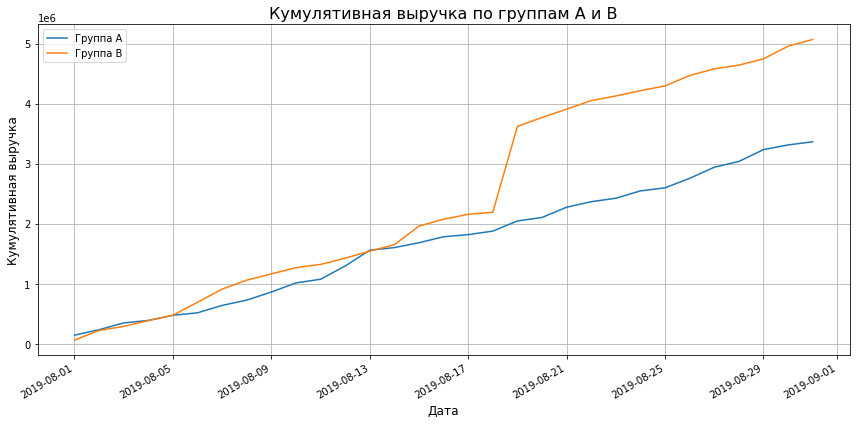

In [16]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(12, 6))  # размер графика

# Линии выручки
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='Группа A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='Группа B')

# Названия и оформление
plt.title('Кумулятивная выручка по группам A и B', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Кумулятивная выручка', fontsize=12)
plt.legend()
plt.grid(True)

# Форматируем даты по оси X
plt.gcf().autofmt_xdate()  # наклон дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.tight_layout()  # автоотступы
plt.show()

**ВЫВОДЫ:**
 - Обе группы демонстрируют стабильный рост выручки.
 - Группа B почти всё время опережает группу A.
 - Критический скачок в группе B: Примерно 19 августа у группы B наблюдается резкий рост выручки. В группе A таких скачков нет — рост более плавный.
 - Разница в итоговой выручке: к концу теста группа B сильно обгоняет A — визуально выручка группы B примерно на 1.5 условной единицы выше.

### Построение графика кумулятивного среднего чека по группам

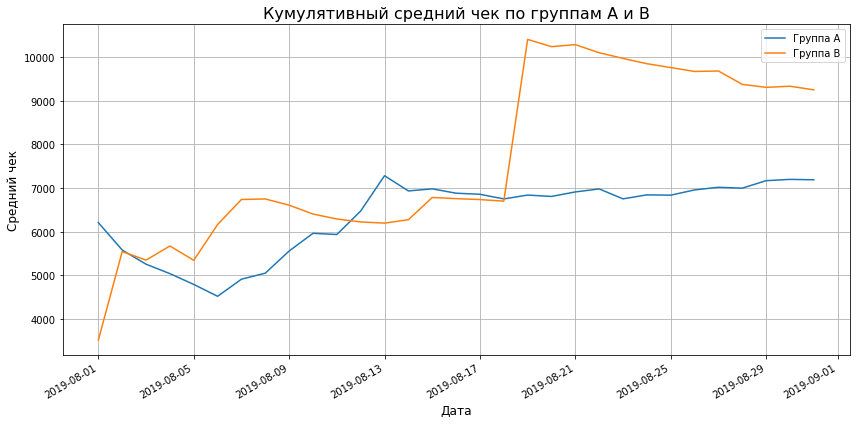

In [17]:

plt.figure(figsize=(12, 6))  # размер графика

# Линии среднего чека
plt.plot(cumulativeRevenueA['date'], 
         cumulativeRevenueA['revenue']/
         cumulativeRevenueA['orders'], 
         label='Группа A')
plt.plot(cumulativeRevenueB['date'], 
         cumulativeRevenueB['revenue']/
         cumulativeRevenueB['orders'], 
         label='Группа B')

# Названия и оформление
plt.title('Кумулятивный средний чек по группам A и B', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Средний чек', fontsize=12)
plt.legend()
plt.grid(True)

# Форматируем даты по оси X
plt.gcf().autofmt_xdate()  # наклон дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.tight_layout()  # автоотступы
plt.show()

**ВЫВОДЫ:**
 - До 19 августа кумулятивный средний чек в группах A и B колебался в диапазоне 5 000–7 000, существенной разницы между группами не наблюдалось.
 - С 19 августа в группе B зафиксирован резкий скачок среднего чека до ~10 200 — это резкое отклонение от предыдущей динамики. Такой же рост мы наблюдали при анализе выручки
 - После пика, средний чек в группе B начал постепенно снижаться, но так и остался заметно выше, чем в группе A до конца наблюдений.
 - Средний чек в группе B оказался выше, но из-за резкого скачка и нестабильности после есть подозрение на выброс. Требуется дальнейшее исследование данных


### Построение графика относительного изменения кумулятивного среднего чека группы B к группе A.

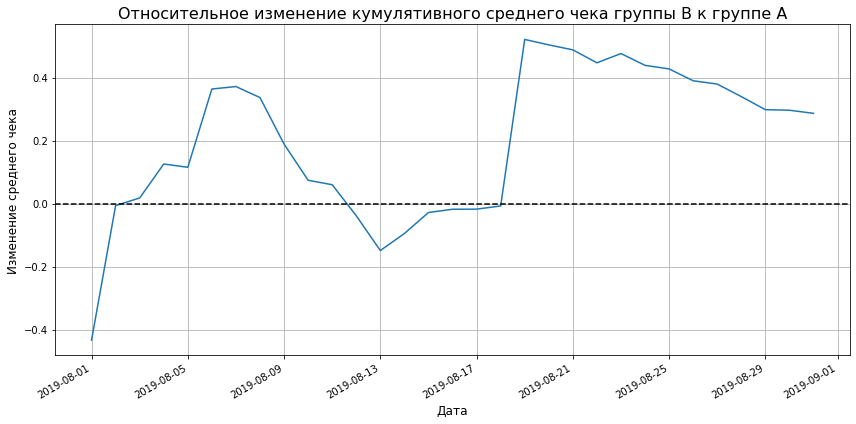

In [18]:
# собираем данные в одном датафрейме
mergedCumulativeRevenue = cumulativeRevenueA.merge(
    cumulativeRevenueB, 
    left_on='date', 
    right_on='date', 
    how='left', 
    suffixes=['A', 'B'])

plt.figure(figsize=(12, 6))  # размер графика

# cтроим отношение средних чеков
plt.plot(mergedCumulativeRevenue['date'], 
         (mergedCumulativeRevenue['revenueB']/
          mergedCumulativeRevenue['ordersB'])/
         (mergedCumulativeRevenue['revenueA']/
          mergedCumulativeRevenue['ordersA'])-1)

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--')

# Названия и оформление
plt.title('Относительное изменение кумулятивного среднего чека группы B к группе А', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Изменение среднего чека', fontsize=12)
plt.grid(True)

# Форматируем даты по оси X
plt.gcf().autofmt_xdate()  # наклон дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.tight_layout()  # автоотступы
plt.show()

**ВЫВОДЫ:**
 - Средний чек в группе B в течение эксперимента в основном превышает чек в группе A, особенно во второй половине теста. Однако резкие колебания и особенно скачок после 19 августа могут быть следствием выброса или крупного заказа. Это искажает реальную картину и требует дополнительного анализа для принятия достоверных решений.
 - Первый пик, вероятно, вызван естественной нестабильностью метрики на малом числе наблюдений, и/или парой крупных, но допустимых заказов в группе B. Это подчеркивает важность анализа метрик на достаточном временном интервале и с очисткой данных от выбросов.

### Построение графика кумулятивного среднего количества заказов на посетителя по группам

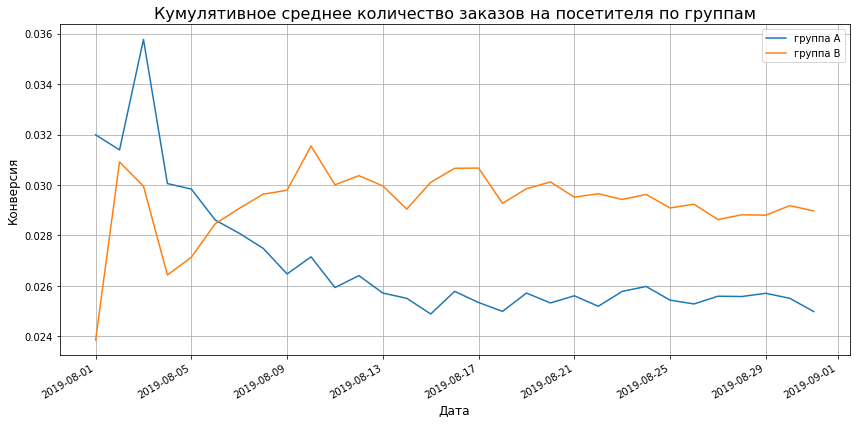

In [19]:
# считаем среднее количество заказов на посетителя
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# отделяем данные по группе A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# отделяем данные по группе B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

plt.figure(figsize=(12, 6))  # размер графика

# строим графики
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='группа A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='группа B')
plt.legend()

# Названия и оформление
plt.title('Кумулятивное среднее количество заказов на посетителя по группам', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Конверсия', fontsize=12)
plt.legend()
plt.grid(True)

# Форматируем даты по оси X
plt.gcf().autofmt_xdate()  # наклон дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.tight_layout()  # автоотступы
plt.show()

**ВЫВОДЫ:**
 - В течение почти всего теста группа B показывает более высокий уровень заказов на посетителя, чем группа A. Это может указывать на положительное влияние изменений, применённых к группе B. Разница выглядит стабильной, особенно во второй половине периода. 

### Построение графика относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

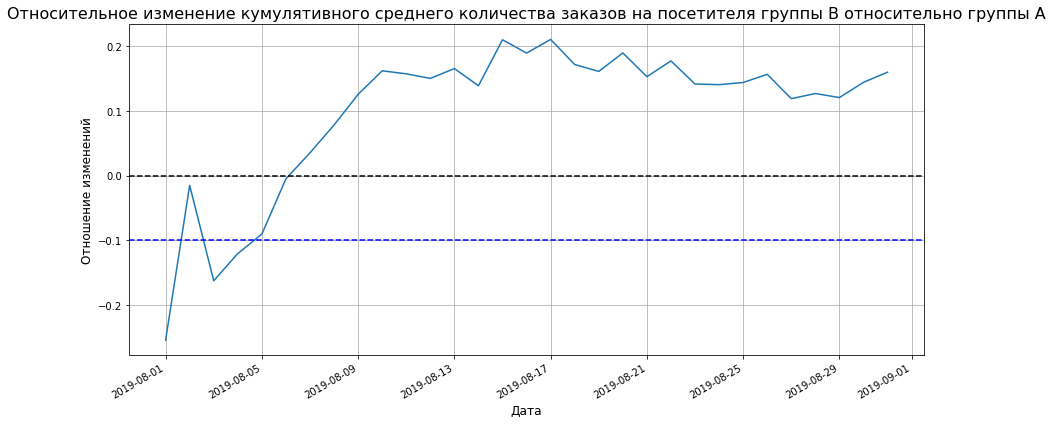

In [20]:
# Объединяем данные по дате, чтобы сравнить конверсии групп A и B
mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(
    cumulativeDataB[['date','conversion']], 
    left_on='date', right_on='date', how='left', 
    suffixes=['A', 'B']) # переименуем столбцы: conversionA и conversionB

plt.figure(figsize=(12, 6))  # размер графика

# Строим линию: относительное изменение конверсии (B относительно A)
plt.plot(mergedCumulativeConversions['date'], 
         (mergedCumulativeConversions['conversionB']/
         mergedCumulativeConversions['conversionA'])-1)
        
# Горизонтальная линия: отсутствие изменений (нулевая разница)
plt.axhline(y=0, color='black', linestyle='--')

# Горизонтальная линия: бизнес-порог допустимого ухудшения (-10%)
plt.axhline(y=-0.1, color='blue', linestyle='--')


# Названия и оформление
plt.title('Относительное изменение кумулятивного среднего количества заказов на посетителя группы B относительно группы A', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Отношение изменений', fontsize=12)
plt.grid(True)

# Форматируем даты по оси X
plt.gcf().autofmt_xdate()  # наклон дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.tight_layout()  # автоотступы
plt.show()


**ВЫВОДЫ:**
 - В начале теста B хуже A, потом кратковременно лучше. Связано с тем, что в начале эксперимента часто наблюдается нестабильность из-за малого числа данных.
 - Начиная с 6 августа кривая уверенно поднимается выше нуля. Пик достигается около 16 августа — прирост конверсии в B превышает +22% по сравнению с A.
 - В целом, группа B демонстрирует устойчивое преимущество по количеству заказов на посетителя, превышающее группу A на 10–20% в разные периоды теста.

### Построение точечного графика количества заказов по пользователям

In [21]:
# Подсчитаем количество заказов по каждому пользователю
orders_per_user = orders.groupby('visitor_id', as_index=False).agg({'transaction_id': 'nunique'})
orders_per_user.columns = ['visitor_id', 'orders']  # переименуем

#посмотрим таблицу, которая получилась от большего количества заказов к меньшему
display(orders_per_user.sort_values('orders', ascending=False))

,visitor_id,orders
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3
...,...,...
331,1438226485,1
332,1452540367,1
333,1455323168,1
334,1455861274,1


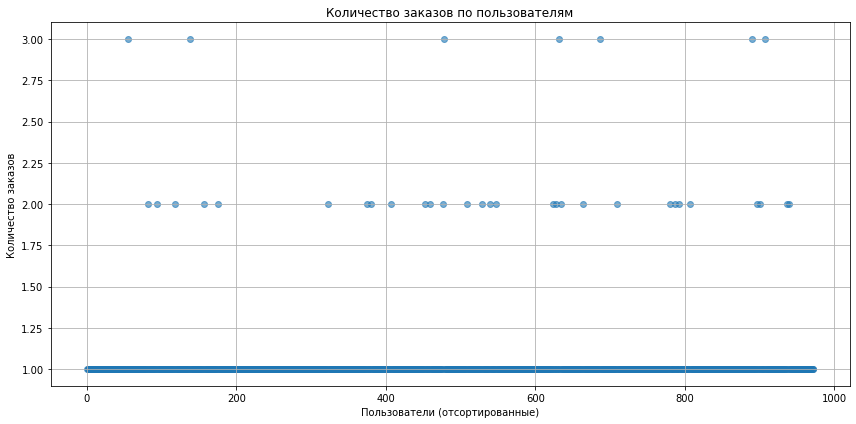

In [22]:
# Строим точечный график
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(x=range(len(orders_per_user)), y=orders_per_user['orders'], alpha=0.6)
plt.title('Количество заказов по пользователям')
plt.xlabel('Пользователи (отсортированные)')
plt.ylabel('Количество заказов')
plt.grid(True)
plt.tight_layout()
plt.show()


**ВЫВОДЫ:**
 - Подавляющее большинство пользователей сделали только 1 заказ — это видно по плотной горизонтальной полосе на уровне y = 1
 - Небольшая доля пользователей совершила 2–3 заказа.

### Расчет 95-й и 99-й перцентили количества заказов на пользователя. Выбор границы для определения аномальных пользователей

In [23]:
# посчитаем 95-й и 99-й перцентили количества заказов на пользователя 
percentiles = np.percentile(orders_per_user['orders'], [95, 99])
print(f"95-й перцентиль: {percentiles[0]}")
print(f"99-й перцентиль: {percentiles[1]}")


95-й перцентиль: 1.0
99-й перцентиль: 2.0


**ВЫВОДЫ:**
 - 95-й перцентиль = 1.0: это значит, что не более 5% пользователей сделали больше 1 заказа.

- 99-й перцентиль = 2.0:только 1% пользователей совершили более 2 заказов.

### Построение точечного графика стоимостей заказов

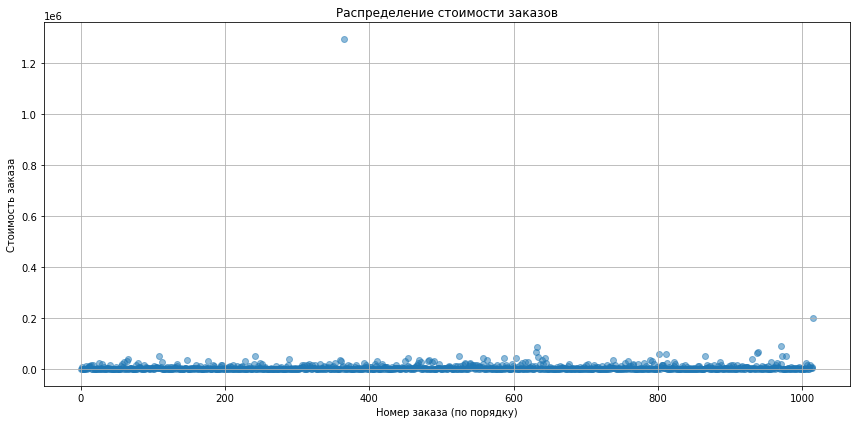

In [24]:
# Строим scatter plot (точечный график)
plt.figure(figsize=(12, 6))
plt.scatter(x=range(len(orders)), y=orders['revenue'], alpha=0.5)

# Подписи и оформление
plt.title('Распределение стоимости заказов')
plt.xlabel('Номер заказа (по порядку)')
plt.ylabel('Стоимость заказа')
plt.grid(True)
plt.tight_layout()
plt.show()


Один заказ имеет стоимость свыше 1.2 млн. — это явный выброс. Рассмотрим график поближе, без этого значения 

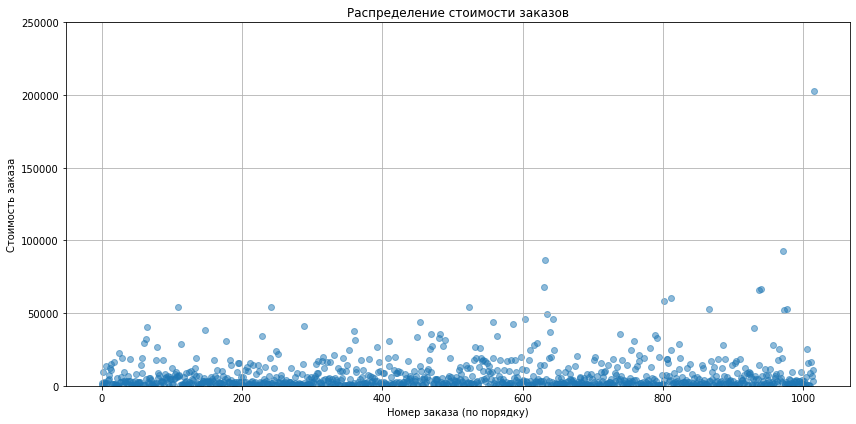

In [25]:
# Строим scatter plot (точечный график)
plt.figure(figsize=(12, 6))
plt.scatter(x=range(len(orders)), y=orders['revenue'], alpha=0.5)
plt.ylim(0, 250000)

# Подписи и оформление
plt.title('Распределение стоимости заказов')
plt.xlabel('Номер заказа (по порядку)')
plt.ylabel('Стоимость заказа')
plt.grid(True)
plt.tight_layout()
plt.show()

**ВЫВОДЫ:**
 - Основная масса заказов укладывается в диапазон от 0 до 50000, что, вероятно, и есть  реальный «рабочий диапазон» заказов.
- Видны единичные заказы от 50000, до 100000, их мало. Они могут исказить средние метрики, особенно если анализировать средний чек.
- Большинство заказов расположены в нижней части графика — что говорит о сильно скошенном распределении

### Расчет 95-й и 99-й перцентили стоимости заказов. Выбор границы для определения аномальных пользователей

In [26]:
# посчитаем 95-й и 99-й перцентили стоимости заказов 
percentiles_2 = np.percentile(orders['revenue'], [95, 99])
print(f"95-й перцентиль: {percentiles_2[0]}")
print(f"99-й перцентиль: {percentiles_2[1]}")

95-й перцентиль: 26785.0
99-й перцентиль: 53904.0


**ВЫВОДЫ:**
 - 5% заказов — дороже 26785
 - Только 1% заказов превышают 53904. Эти заказы можно уверенно считать аномальными
 - Таким образом, стоимость заказа от 26785 и выше можно считать аномальной по сравнению с основной массой данных

### Расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным

Сформулируем гипотезы:
   - H₀ (нулевая): Среднее количество заказов на одного посетителя в группах A и B одинаково.
   - H₁ (альтернативная): Среднее количество заказов на одного пользователя в группах A и B различается.

Названия столбцов данных:
- date — дата;
- ordersPerDateA — количество заказов в выбранную дату в группе A;
- revenuePerDateA — суммарная выручка в выбранную дату в группе A;
- ordersPerDateB — количество заказов в выбранную дату в группе B;
- revenuePerDateB — суммарная выручка в выбранную дату в группе B;
- ordersCummulativeA — суммарное число заказов до выбранной даты включительно в группе A;
- revenueCummulativeA — суммарная выручка до выбранной даты включительно в группе A;
- ordersCummulativeB — суммарное количество заказов до выбранной даты включительно в группе B;
- revenueCummulativeB — суммарная выручка до выбранной даты включительно в группе B;
- visitorsPerDateA — количество пользователей в выбранную дату в группе A;
- visitorsPerDateB — количество пользователей в выбранную дату в группе B;
- visitorsCummulativeA — количество пользователей до выбранной даты включительно в группе A;
- visitorsCummulativeB — количество пользователей до выбранной даты включительно в группе B.

Подготовим данные. Изучим код и устройство таблицы data

In [27]:
# Ежедневное  количество пользователей в группе  A
visitorsADaily = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

# накопительное количество пользователей в группе A на каждую дату
visitorsACummulative = visitorsADaily.apply(
    lambda x: visitorsADaily[visitorsADaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateA': 'sum'}
    ),
    axis=1,
)
visitorsACummulative.columns = ['date', 'visitorsCummulativeA']

# Ежедневное  количество пользователей в группе B
visitorsBDaily = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']

#накопительное количество пользователей в группе B на каждую дату
visitorsBCummulative = visitorsBDaily.apply(
    lambda x: visitorsBDaily[visitorsBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateB': 'sum'}
    ),
    axis=1,
)
visitorsBCummulative.columns = ['date', 'visitorsCummulativeB']

# Ежедневное количество заказов и выручки в группе A
ordersADaily = (
    orders[orders['group'] == 'A'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
ordersADaily.columns = ['date', 'ordersPerDateA', 'revenuePerDateA']


# Накопительное (кумулятивное) количество заказов и выручки по дате для группы A
ordersACummulative = ordersADaily.apply(
    lambda x: ordersADaily[ordersADaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateA': 'sum', 'revenuePerDateA': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersACummulative.columns = [
    'date',
    'ordersCummulativeA',
    'revenueCummulativeA',
]

# Ежедневное количество заказов и выручки в группе A
ordersBDaily = (
    orders[orders['group'] == 'B'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
ordersBDaily.columns = ['date', 'ordersPerDateB', 'revenuePerDateB']

# Накопительное (кумулятивное) количество заказов и выручки по дате для группы B
ordersBCummulative = ordersBDaily.apply(
    lambda x: ordersBDaily[ordersBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateB': 'sum', 'revenuePerDateB': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersBCummulative.columns = [
    'date',
    'ordersCummulativeB',
    'revenueCummulativeB',
]

# Объединяем все метрики в одну таблицу по дате (daily + cumulative для обеих групп)
data = (
    ordersADaily.merge(
        ordersBDaily, left_on='date', right_on='date', how='left'
    )
    .merge(ordersACummulative, left_on='date', right_on='date', how='left')
    .merge(ordersBCummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsADaily, left_on='date', right_on='date', how='left')
    .merge(visitorsBDaily, left_on='date', right_on='date', how='left')
    .merge(visitorsACummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsBCummulative, left_on='date', right_on='date', how='left')
)

display(data.head(5))

,date,ordersPerDateA,revenuePerDateA,ordersPerDateB,revenuePerDateB,ordersCummulativeA,revenueCummulativeA,ordersCummulativeB,revenueCummulativeB,visitorsPerDateA,visitorsPerDateB,visitorsCummulativeA,visitorsCummulativeB
0,2019-08-01,23,142779,17,59758,23,142779,17,59758,719,713,719,713
1,2019-08-02,19,91602,23,162043,42,234381,40,221801,619,581,1338,1294
2,2019-08-03,24,112473,14,67049,66,346854,54,288850,507,509,1845,1803
3,2019-08-04,11,41176,14,96890,77,388030,68,385740,717,770,2562,2573
4,2019-08-05,22,86383,21,89908,99,474413,89,475648,756,707,3318,3280


Проанализируем, есть ли статистически значимая разница в среднем количестве заказов на одного пользователя между группами A и B на основе всех пользователей, включая тех, кто не сделал ни одного заказа.

In [28]:

#Создадим переменные ordersByUsersA и ordersByUsersB со столбцами ['visitor_id', 'orders']. 
#В них для пользователей, которые заказывали хотя бы 1 раз, укажем число совершённых заказов. 
ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersA.columns = ['visitor_id', 'orders']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersB.columns = ['visitor_id', 'orders']


# Объявим переменные sampleA и sampleB, в которых пользователям из разных групп будет
#соответствовать количество заказов. 
#Тем, кто ничего не заказал, будут соответствовать нули.

sampleA = pd.concat([ordersByUsersA['orders'],
                     pd.Series(0, index=np.arange(
                     data['visitorsPerDateA'].sum() - 
                     len(ordersByUsersA['orders'])), 
                     name='orders')],axis=0)

sampleB = pd.concat([ordersByUsersB['orders'],
                     pd.Series(0, index=np.arange(
                     data['visitorsPerDateB'].sum() - 
                     len(ordersByUsersB['orders'])), 
                    name='orders')],axis=0)


# Проверим статистическую значимость различий, используя тест Манна–Уитни, 
#так как данные — не нормально распределены (много нулей и выбросов)
p_value = stats.mannwhitneyu(sampleA, sampleB)[1]


#Выведем относительный прирост среднего числа заказов группы B

relative_difference = sampleB.mean() / sampleA.mean() - 1

print(f"p-value теста Манна–Уитни: {p_value:.3f}")
print(f"Относительный прирост среднего числа заказов в группе B по сравнению с группой A: {relative_difference:.1%}")


p-value теста Манна–Уитни: 0.011
Относительный прирост среднего числа заказов в группе B по сравнению с группой A: 16.0%


**ВЫВОДЫ:**
 - Так как p-value 0.011 < 0.05, мы отвергаем нулевую гипотезу. Это означает, что различия между группами статистически значимы, а значит — среднее количество заказов на одного пользователя в группах A и B действительно различается

 - Среднее количество заказов на одного пользователя в группе B выше, чем в группе A на 16%. Это говорит о том, что группа B демонстрирует существенно лучший результат по ключевой метрике.

### Расчет статистической значимости различий в среднем чеке заказа между группами по «сырым» данным

Сформулируем гипотезы:
   - H₀ (нулевая): Различий в среднем чеке между группами A и B нет.
   - H₁ (альтернативная): Различия в среднем чеке между группами A и B есть.

In [29]:
# p-value теста Манна–Уитни
p_value = stats.mannwhitneyu(
    orders[orders['group'] == 'A']['revenue'],
    orders[orders['group'] == 'B']['revenue'],
)[1]

# Относительное изменение среднего чека группы B к A
relative_change = (
    orders[orders['group'] == 'B']['revenue'].mean() /
    orders[orders['group'] == 'A']['revenue'].mean() - 1
)

# Вывод результатов
print(f"p-value теста Манна–Уитни для среднего чека: {p_value:.3f}")
print(f"Относительное изменение среднего чека в группе B по сравнению с группой A: {relative_change:.1%}")


p-value теста Манна–Уитни для среднего чека: 0.829
Относительное изменение среднего чека в группе B по сравнению с группой A: 28.7%


**ВЫВОДЫ:**
 - p-value = 0.829 — это намного больше порогового значения 0.05, поэтому нет оснований отвергать нулевую гипотезу. Это значит, что статистически значимых различий в среднем чеке между группами A и B нет.

- Несмотря на то, что средний чек в группе B выше на 28.7%, эта разница может быть обусловлена случайными колебаниями (например, выбросами или небольшим числом крупных заказов), а не реальным эффектом.

### Расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

Ранее были получены 95-й и 99-й перцентили средних чеков - 26785 и 53904, а 95-й и 99-й перцентили количества заказов на одного пользователя равны - 1 и 2 на пользователя.

Примем за аномальных пользователей тех, кто совершил от 2 заказов или совершил заказ дороже 26785. Так мы уберём 1% пользователей с наибольшим числом заказов и 5% пользователей с дорогими заказами. 

Сделаем срезы пользователей с числом заказов больше 2 — usersWithManyOrders и пользователей, совершивших заказы дороже 26785 — usersWithExpensiveOrders. Объединим их в таблице abnormalUsers. Узнаем, сколько всего аномальных пользователей атрибутом shape.

In [30]:
# Находим пользователей, совершивших более 2 заказов (по 99-му перцентилю)

usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > 2]['visitor_id'],
        ordersByUsersB[ordersByUsersB['orders'] > 2]['visitor_id'],
    ],
    axis=0,
)

# Находим пользователей, сделавших хотя бы один заказ дороже 26785
usersWithExpensiveOrders = orders[orders['revenue'] > 26785]['visitor_id']

# Объединяем аномальных пользователей: много заказов или дорогие заказы
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
# Выводим первых 5 аномальных пользователей и их общее количество
print("Первые 5 аномальных пользователей:\n", abnormalUsers.head())
print(f"Общее количество аномальных пользователей: {abnormalUsers.shape[0]}")

Первые 5 аномальных пользователей:
 568     113298937
1099    148427295
928     204675465
33      249864742
684     358944393
Name: visitor_id, dtype: int64
Общее количество аномальных пользователей: 58


**ВЫВОДЫ:**
- В результате фильтрации были выявлены 55 аномальных пользователя, которые: совершили более 2 заказов (что выше 99-го перцентиля), либо оформили хотя бы один заказ на сумму более 26785 рублей (выше 95-го перцентиля по стоимости заказа).

- Эти пользователи могут исказить распределение метрик, особенно средний чек и среднее количество заказов на посетителя. Поэтому они будут исключены из анализа "очищенных" данных для более объективного сравнения групп A и B.

После исключения 55 аномальных пользователей необходимо оценить, насколько они влияли на результаты теста.
Для этого пересчитаем статистическую значимость различий в конверсии между группами A и B на очищенных данных.

Сформулируем гипотезы:
   - H₀ (нулевая): Среднее количество заказов на одного пользователя одинаково в группах A и B
   - H₁ (альтернативная): Среднее количество заказов на одного пользователя в группах A и B различается

In [31]:
# Формируем выборку количества заказов на одного пользователя в группе A без аномалий
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['visitor_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)
# Формируем выборку количества заказов на одного пользователя в группе B без аномалий
sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['visitor_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)
# Расчёт статистической значимости (тест Манна–Уитни)
p_value = stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]

# Относительный прирост среднего количества заказов
relative_change = sampleBFiltered.mean() / sampleAFiltered.mean() - 1

# вывод результата
print(f"p-value теста Манна–Уитни (без аномалий): {p_value:.3f}")
print(f"Относительный прирост среднего количества заказов в группе B: {relative_change:.1%}")


p-value теста Манна–Уитни (без аномалий): 0.012
Относительный прирост среднего количества заказов в группе B: 18.2%


**ВЫВОДЫ:**

- Гипотеза о росте среднего количества заказов на одного пользователя в группе B по сравнению с A подтверждается. В обоих случаях (с аномалиями и без) тест Манна–Уитни показывает статистически значимое различие:
  - По "сырым" данным: прирост +16.0%, p = 0.011
  - По очищенным данным: прирост +18.2%, p = 0.012

Это означает, что группа B оформляла больше заказов, и этот результат надёжный даже без учёта аномальных пользователей.

- После исключения 55 аномальных пользователей (многозаказных и с дорогими чеками), результат сохраняет значимость и даёт уверенность в эффективности изменений в группе B.

### Расчет статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным

Сформулируем гипотезы:
   - H₀ (нулевая): Различий в среднем чеке между группами A и B нет.
   - H₁ (альтернативная): Различия в среднем чеке между группами A и B есть.

In [32]:
p_value = stats.mannwhitneyu(
            orders[
                np.logical_and(
                    orders['group'] == 'A',
                    np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
            orders[
                np.logical_and(
                    orders['group'] == 'B',
                    np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
        )[1]


relative_change = (
    orders[
        np.logical_and(
            orders['group'] == 'B',
            np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
        )
    ]['revenue'].mean()
    /
    orders[
        np.logical_and(
            orders['group'] == 'A',
            np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
        )
    ]['revenue'].mean()
    - 1
)

# Вывод результатов
print(f"p-value теста Манна–Уитни для среднего чека: {p_value:.3f}")
print(f"Относительное изменение среднего чека в группе B по сравнению с группой A: {relative_change:.1%}")

p-value теста Манна–Уитни для среднего чека: 0.646
Относительное изменение среднего чека в группе B по сравнению с группой A: -4.8%


**ВЫВОДЫ:**
- p-value = 0.646, соответственно принимаем нулевую гипотезу - нет статистически значимых различий в среднем чеке между группами A и B, а относительное изменение: -4.8%, т.е. средний чек в группе B немного ниже, чем в группе A
- Средний чек в группах A и B не отличается статистически значимо ни до, ни после очистки данных от выбросов. Разница в +28.7% по «сырым» данным оказалась ложной и была вызвана влиянием отдельных аномальных заказов. После фильтрации данных средний чек в группе B даже оказался на 4.8% ниже, но эта разница не является значимой. Следовательно, гипотеза о повышении среднего чека в группе B не подтверждается.

**CONCLUSIONS AND RECOMMENDATIONS**
 - 







**Overall Conclusions from A/B Testing and Hypothesis Prioritization:**

- RICE prioritization helped identify ideas with the greatest potential impact.  
Hypotheses with higher user reach (e.g., subscription forms or product recommendations) received higher priority compared to more niche ideas such as birthday discounts. This makes RICE a more realistic and strategically valuable tool for business decision-making.

---

- The average number of orders per user in Group B is statistically significantly higher than in Group A:
  - Increase based on raw data: +16.0%, p = 0.011  
  - Increase based on filtered data: +18.2%, p = 0.012  
    - This result is stable and remains significant after removing outliers, indicating a real effect of the changes in Group B.

---

- The average order value does not differ significantly between Groups A and B:
  - Raw data: p = 0.829, increase +28.7%  
  - Filtered data: p = 0.646, change –4.8%  
    - Therefore, the observed difference in average order value was driven by outliers and is not a reliable effect. The hypothesis of increasing average order value is not supported.

---

- Final Decision:
  - Stop the test and declare Group B as the winner  
  - Group B shows a statistically significant increase in the number of orders per user, which is the key business metric  
  - The average order value remains stable, confirming that the growth in total orders is driven by increased user activity rather than random spikes  